# Análise Exploratória de Dados

Este notebook explora os dados da tabela `vendas`, carregada no PostgreSQL pelo pipeline ETL do projeto.

Objetivos desta análise:
- validar rapidamente a carga realizada pelo ETL
- entender volume e receita ao longo do tempo
- comparar categorias, canais e UFs
- identificar padrões iniciais para análises futuras


## Setup

Antes de executar este notebook:

1. garanta que o PostgreSQL esteja no ar com `docker compose up -d postgres`
2. garanta que o ETL já tenha carregado a tabela `vendas`
3. se estiver usando um ambiente local, instale `matplotlib` caso ainda nao esteja disponivel


In [2]:
from pathlib import Path
import os

import pandas as pd
from sqlalchemy import create_engine

try:
    import matplotlib.pyplot as plt
except ImportError as exc:
    raise ImportError(
        "matplotlib nao esta instalado. Rode: pip install matplotlib"
    ) from exc

plt.style.use("ggplot")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda value: f"{value:,.2f}")


In [3]:
def load_dotenv_file(env_path: Path) -> None:
    if not env_path.exists():
        raise FileNotFoundError(f"Arquivo .env nao encontrado em: {env_path}")

    for raw_line in env_path.read_text().splitlines():
        line = raw_line.strip()
        if not line or line.startswith("#") or "=" not in line:
            continue
        key, value = line.split("=", 1)
        os.environ.setdefault(key.strip(), value.strip())


project_root = Path.cwd().parent
load_dotenv_file(project_root / ".env")

DB_HOST = os.getenv("DB_HOST", "localhost")
DB_PORT = os.getenv("DB_PORT", "5432")
DB_NAME = os.environ["POSTGRES_DB"]
DB_USER = os.environ["POSTGRES_USER"]
DB_PASS = os.environ["POSTGRES_PASSWORD"]

engine = create_engine(
    f"postgresql+psycopg2://{DB_USER}:{DB_PASS}@{DB_HOST}:{DB_PORT}/{DB_NAME}"
)

print("Conexao com PostgreSQL configurada com sucesso.")


Conexao com PostgreSQL configurada com sucesso.


In [4]:
query = "select * from vendas order by data_venda, id"
df = pd.read_sql(query, engine, parse_dates=["data_venda"])

print(f"Total de linhas: {len(df)}")
print(f"Periodo: {df['data_venda'].min().date()} ate {df['data_venda'].max().date()}")
df.head()


Total de linhas: 1960
Periodo: 2025-01-01 ate 2025-12-31


,id,data_venda,categoria,produto,quantidade,preco_unit,canal,uf,receita
0,1,2025-01-01,Moda,Produto B,3,59.90,Marketplace,MA,179.70
1,2,2025-01-01,Eletrônicos,Produto A,2,29.90,Marketplace,PE,59.80
2,3,2025-01-01,Beleza,Produto E,3,399.90,Site,MA,"1,199.70"
3,4,2025-01-01,Casa,Produto C,3,29.90,App,MA,89.70
4,5,2025-01-01,Beleza,Produto D,3,29.90,Marketplace,PI,89.70


## Validacao inicial

Aqui verificamos estrutura, estatisticas basicas e se ainda restou alguma inconsistência apos o ETL.

In [5]:
display(df.info())
display(df.describe(include="all"))

checks = pd.Series(
    {
        "quantidade_invalida": int((df["quantidade"] <= 0).sum()),
        "preco_invalido": int((df["preco_unit"] <= 0).sum()),
        "categoria_nula": int(df["categoria"].isna().sum()),
        "uf_em_branco": int((df["uf"].astype(str).str.strip() == "").sum()),
    }
)
checks.to_frame("total")


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1960 entries, 0 to 1959
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   id          1960 non-null   int64         
 1   data_venda  1960 non-null   datetime64[ns]
 2   categoria   1960 non-null   object        
 3   produto     1960 non-null   object        
 4   quantidade  1960 non-null   int64         
 5   preco_unit  1960 non-null   float64       
 6   canal       1960 non-null   object        
 7   uf          1960 non-null   object        
 8   receita     1960 non-null   float64       
dtypes: datetime64[ns](1), float64(2), int64(2), object(4)
memory usage: 137.9+ KB


None

,id,data_venda,categoria,produto,quantidade,preco_unit,canal,uf,receita
count,"1,960.00",1960,1960,1960,"1,960.00","1,960.00",1960,1960,"1,960.00"
unique,NaN,NaN,5,5,NaN,NaN,3,8,NaN
top,NaN,NaN,Eletrônicos,Produto B,NaN,NaN,App,PI,NaN
freq,NaN,NaN,498,411,NaN,NaN,661,314,NaN
mean,980.50,2025-07-01 22:03:55.102040832,NaN,NaN,2.93,133.30,NaN,NaN,385.67
min,1.00,2025-01-01 00:00:00,NaN,NaN,1.00,19.90,NaN,NaN,19.90
25%,490.75,2025-03-31 00:00:00,NaN,NaN,2.00,29.90,NaN,NaN,89.70
50%,980.50,2025-07-02 00:00:00,NaN,NaN,3.00,79.90,NaN,NaN,199.90
75%,"1,470.25",2025-10-03 06:00:00,NaN,NaN,4.00,199.90,NaN,NaN,499.50
max,"1,960.00",2025-12-31 00:00:00,NaN,NaN,5.00,399.90,NaN,NaN,"1,999.50"


,total
quantidade_invalida,0
preco_invalido,0
categoria_nula,0
uf_em_branco,0


## Indicadores gerais

In [6]:
summary = pd.DataFrame(
    {
        "indicador": [
            "Total de vendas",
            "Receita total",
            "Ticket medio",
            "Quantidade media por venda",
            "Categorias distintas",
            "Canais distintos",
            "UFs distintas",
        ],
        "valor": [
            len(df),
            df["receita"].sum(),
            df["receita"].mean(),
            df["quantidade"].mean(),
            df["categoria"].nunique(),
            df["canal"].nunique(),
            df["uf"].nunique(),
        ],
    }
)
summary


,indicador,valor
0,Total de vendas,"1,960.00"
1,Receita total,"755,906.00"
2,Ticket medio,385.67
3,Quantidade media por venda,2.93
4,Categorias distintas,5.00
5,Canais distintos,3.00
6,UFs distintas,8.00


## Evolucao temporal

Analise da receita e do volume agregados por mes.

In [7]:
monthly = (
    df.assign(mes=df["data_venda"].dt.to_period("M").dt.to_timestamp())
    .groupby("mes", as_index=False)
    .agg(
        total_vendas=("id", "count"),
        quantidade_total=("quantidade", "sum"),
        receita_total=("receita", "sum"),
        ticket_medio=("receita", "mean"),
    )
)
monthly


,mes,total_vendas,quantidade_total,receita_total,ticket_medio
0,2025-01-01,157,470,"73,153.00",465.94
1,2025-02-01,179,509,"64,909.10",362.62
2,2025-03-01,156,447,"66,395.30",425.61
3,2025-04-01,162,450,"61,925.00",382.25
4,2025-05-01,142,402,"54,249.80",382.04
5,2025-06-01,176,520,"66,528.00",378.00
6,2025-07-01,173,527,"69,567.30",402.12
7,2025-08-01,160,460,"57,804.00",361.27
8,2025-09-01,153,468,"53,983.20",352.83
9,2025-10-01,167,496,"64,270.40",384.85


TypeError: tz must be string or tzinfo subclass, not <matplotlib.category.UnitData object at 0x7b3d33f6ac00>.

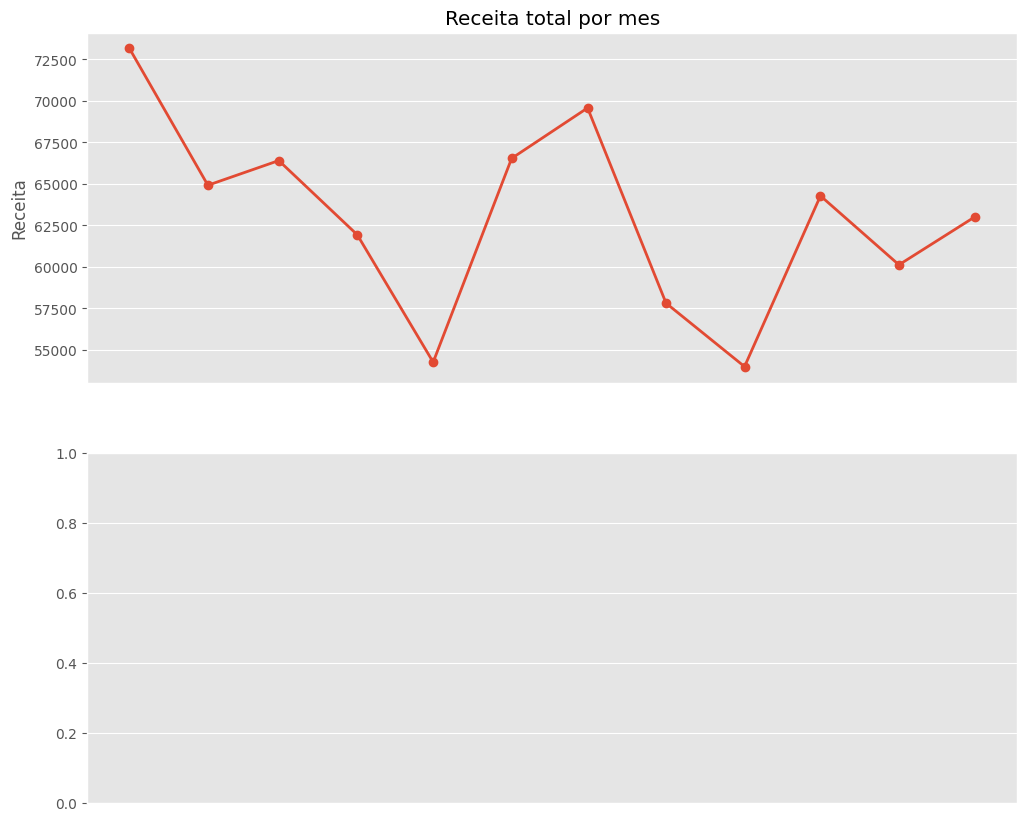

In [8]:
fig, axes = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

axes[0].plot(monthly["mes"], monthly["receita_total"], marker="o", linewidth=2)
axes[0].set_title("Receita total por mes")
axes[0].set_ylabel("Receita")

axes[1].bar(monthly["mes"].dt.strftime("%Y-%m"), monthly["total_vendas"], color="#4C72B0")
axes[1].set_title("Quantidade de vendas por mes")
axes[1].set_ylabel("Vendas")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()


## Categorias

Comparacao entre categorias em volume, receita e ticket medio.

In [ ]:
category_summary = (
    df.groupby("categoria", as_index=False)
    .agg(
        total_vendas=("id", "count"),
        quantidade_total=("quantidade", "sum"),
        receita_total=("receita", "sum"),
        ticket_medio=("receita", "mean"),
    )
    .sort_values("receita_total", ascending=False)
)
category_summary


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(category_summary["categoria"], category_summary["receita_total"], color="#55A868")
axes[0].set_title("Receita por categoria")
axes[0].set_ylabel("Receita")
axes[0].tick_params(axis="x", rotation=25)

axes[1].bar(category_summary["categoria"], category_summary["total_vendas"], color="#C44E52")
axes[1].set_title("Total de vendas por categoria")
axes[1].set_ylabel("Vendas")
axes[1].tick_params(axis="x", rotation=25)

plt.tight_layout()
plt.show()


## Canais de venda

Aqui avaliamos como a receita se distribui entre `Site`, `App` e `Marketplace`.

In [ ]:
channel_summary = (
    df.groupby("canal", as_index=False)
    .agg(
        total_vendas=("id", "count"),
        receita_total=("receita", "sum"),
        ticket_medio=("receita", "mean"),
    )
    .sort_values("receita_total", ascending=False)
)
channel_summary


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].pie(
    channel_summary["receita_total"],
    labels=channel_summary["canal"],
    autopct="%1.1f%%",
    startangle=90,
)
axes[0].set_title("Participacao da receita por canal")

axes[1].bar(channel_summary["canal"], channel_summary["ticket_medio"], color="#8172B2")
axes[1].set_title("Ticket medio por canal")
axes[1].set_ylabel("Ticket medio")

plt.tight_layout()
plt.show()


## Desempenho por UF

In [ ]:
uf_summary = (
    df.groupby("uf", as_index=False)
    .agg(
        total_vendas=("id", "count"),
        receita_total=("receita", "sum"),
    )
    .sort_values("receita_total", ascending=True)
)
uf_summary


In [ ]:
plt.figure(figsize=(10, 6))
plt.barh(uf_summary["uf"], uf_summary["receita_total"], color="#64B5CD")
plt.title("Receita total por UF")
plt.xlabel("Receita")
plt.ylabel("UF")
plt.tight_layout()
plt.show()


## Cruzamento categoria x canal

Esta visao ajuda a entender em quais canais cada categoria gera mais receita.

In [ ]:
pivot_revenue = pd.pivot_table(
    df,
    index="categoria",
    columns="canal",
    values="receita",
    aggfunc="sum",
    fill_value=0,
)
pivot_revenue


In [ ]:
pivot_revenue.plot(kind="bar", stacked=True, figsize=(12, 6), colormap="tab20c")
plt.title("Receita por categoria e canal")
plt.ylabel("Receita")
plt.xlabel("Categoria")
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()


## Leituras iniciais sugeridas

- verificar se alguma categoria apresenta ticket muito acima das demais
- investigar sazonalidade mensal de receita e quantidade
- comparar canais que trazem mais volume com canais que trazem maior ticket medio
- avaliar se existe concentracao excessiva de receita em poucas UFs

Como proximo passo, este notebook pode evoluir para uma camada mais analitica, com metricas de cohort, sazonalidade semanal e consultas SQL dedicadas.